Feature 1 - Transaction Parser

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [ ]:
from google.colab import files
uploadded = files.upload()

Saving Data set for DADS June.csv to Data set for DADS June.csv


In [ ]:
df = pd.read_csv("Data set for DADS June.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [ ]:
df.head()

,Date,Time,Description,Type,Amount,Balance,Mode,Ref
0,2024-01-01,03:11,AMAZON SELLER SVCS,Debit,₹2462,678275.0,UPI,TXN190872
1,01-Jan-24,05:44,BHIM-BMTC,DR,50.00,681007.0,UPI,TXN143064
2,01-Jan-24,09:35,NEFT-TECHCRUSH LABS-SALARY MAY24,CR,₹84728,484728.0,NEFT,TXN246316
3,2024-01-01,14:07,UPI-AMAN-8934@OKAXIS,Debit,₹1828,-748745.0,UPI,TXN569226
4,01 Jan 2024,14:23,BHIM-BLINKIT,Debit,270.00,680737.0,UPI,TXN968962


In [ ]:
print("Shape :", df.shape)

print("\nColumns :")
print(df.columns)

print("\nDataset Information")
df.info()

Shape : (1328, 8)

Columns :
Index(['Date', 'Time', 'Description', 'Type', 'Amount', 'Balance', 'Mode',
       'Ref'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1328 non-null   object 
 1   Time         1328 non-null   object 
 2   Description  1328 non-null   object 
 3   Type         1328 non-null   object 
 4   Amount       1328 non-null   object 
 5   Balance      1328 non-null   float64
 6   Mode         1328 non-null   object 
 7   Ref          1328 non-null   object 
dtypes: float64(1), object(7)
memory usage: 83.1+ KB


In [ ]:
print(df.isnull().sum())

Date           0
Time           0
Description    0
Type           0
Amount         0
Balance        0
Mode           0
Ref            0
dtype: int64


In [ ]:
print("Duplicate Rows Before :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After :", df.duplicated().sum())
print("New Shape :", df.shape)

Duplicate Rows Before : 18
Duplicate Rows After : 0
New Shape : (1310, 8)


In [ ]:
def parse_date(date):
    date = str(date).strip()

    formats = [
        "%Y-%m-%d",
        "%d-%b-%y",
        "%d %b %Y",
        "%d/%m/%y"
    ]

    for fmt in formats:
        try:
            return datetime.strptime(date, fmt)
        except ValueError:
            continue

    return pd.NaT

df["Date"] = df["Date"].apply(parse_date)

print(df["Date"].head(20))
print("Invalid Dates :", df["Date"].isnull().sum())

0    2024-01-01
1    2024-01-01
2    2024-01-01
3    2024-01-01
4    2024-01-01
5    2024-01-01
6    2024-01-01
7    2024-01-01
8    2024-01-02
9    2024-01-02
10   2024-01-02
11   2024-01-02
12   2024-01-02
13   2024-01-02
14   2024-01-02
15   2024-01-02
16   2024-01-02
17   2024-01-02
18   2024-01-03
19   2024-01-03
Name: Date, dtype: datetime64[ns]
Invalid Dates : 0


In [ ]:
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print(df["Amount"].head())
print("Invalid Amounts :", df["Amount"].isnull().sum())

0     2462.0
1       50.0
2    84728.0
3     1828.0
4      270.0
Name: Amount, dtype: float64
Invalid Amounts : 0


In [ ]:
df["Type"] = df["Type"].str.strip().str.lower()

df["Type"] = df["Type"].replace({
    "dr": "debit",
    "cr": "credit",
    "debit": "debit",
    "credit": "credit"
})

print(df["Type"].value_counts())

Type
debit     1304
credit       6
Name: count, dtype: int64


In [ ]:
print("=" * 60)
print("FEATURE 1 : TRANSACTION PARSER")
print("=" * 60)

print("Rows :", len(df))
print("Columns :", len(df.columns))
print("Duplicate Rows :", df.duplicated().sum())
print("Invalid Dates :", df["Date"].isnull().sum())
print("Invalid Amounts :", df["Amount"].isnull().sum())

print("=" * 60)
print("Feature 1 Completed Successfully ✅")

FEATURE 1 : TRANSACTION PARSER
Rows : 1310
Columns : 8
Duplicate Rows : 0
Invalid Dates : 0
Invalid Amounts : 0
Feature 1 Completed Successfully ✅


Feature 2 - Vendor Extractor

In [ ]:
# Convert Description to uppercase

df["Description"] = df["Description"].astype(str).str.upper().str.strip()

print("Description Column Cleaned Successfully ✅")

Description Column Cleaned Successfully ✅


In [ ]:
vendor_dict = {
    # Food Delivery
    "SWIGGY": "Swiggy",
    "BUNDL": "Swiggy",
    "ZOMATO": "Zomato",
    "INSTAMART": "Swiggy Instamart",

    # Quick Commerce
    "ZEPTO": "Zepto",
    "BLINKIT": "Blinkit",
    "GROFERS": "Blinkit",
    "BIGBASKET": "BigBasket",
    "DMART": "DMart",
    "AVENUE SUPERMARTS": "DMart",

    # Shopping
    "AMAZON": "Amazon",
    "AMZN": "Amazon",
    "FLIPKART": "Flipkart",
    "MYNTRA": "Myntra",
    "AJIO": "Ajio",
    "NYKAA": "Nykaa",

    # Transport
    "UBER": "Uber",
    "OLA": "Ola",
    "RAPIDO": "Rapido",
    "ANI TECHNOLOGIES": "Ola",
    "BMTC": "BMTC",

    # Fuel
    "HP PETROL": "HP Petrol",

    # Cafes & Restaurants
    "STARBUCKS": "Starbucks",
    "TATA STARBUCKS": "Starbucks",
    "CCD": "Cafe Coffee Day",
    "CAFE COFFEE DAY": "Cafe Coffee Day",
    "THIRDWAVE": "Third Wave Coffee",
    "TRUFFLES": "Truffles",
    "RESTAURANT": "Restaurant",

    # Bills
    "BESCOM": "BESCOM",
    "BANGALORE ELEC SUPPLY": "BESCOM",
    "BWSSB": "BWSSB",
    "AIRTEL": "Airtel",
    "VI POSTPAID": "Vi",

    # Entertainment
    "BOOKMYSHOW": "BookMyShow",
    "BMS": "BookMyShow",

    # Investment
    "ZERODHA": "Zerodha",
    "GROWW": "Groww",

    # OTT
    "NETFLIX": "Netflix",
    "SPOTIFY": "Spotify",
    "HOTSTAR": "Hotstar",
    "YOUTUBE": "YouTube",

    # ATM
    "ATM": "ATM Withdrawal",
    # Salary
"TECHCRUSH LABS": "TechCrush Labs",

# Person to Person (UPI)
"OKAXIS": "Person Transfer",

# Transport
"ROPPEN": "Rapido",

# Rent
"LANDLORD": "House Rent",

# Telecom
"JIORECHARGE": "Jio",
"RELIANCE JIO": "Jio",

# Fuel
"BPCL": "BPCL Petrol",
"INDIAN OIL": "Indian Oil",
"IOC": "Indian Oil",

# Food
"DINEOUT": "Dineout",
"MEGHANA FOODS": "Meghana Foods",

# Coffee
"COFFEE DAY": "Cafe Coffee Day",
"THIRD WAVE": "Third Wave Coffee",

# Shopping
"FKART": "Flipkart",
"FSN E-COMMERCE": "Nykaa",
"KIRANAKART": "Zepto",
"INNOVATIVE RETAIL": "Reliance Smart",

# Entertainment
"BIGTREE": "BookMyShow",
"STAR INDIA": "Disney+ Hotstar"
}

In [ ]:
# Function to Extract Vendor

def extract_vendor(description):

    for keyword, vendor in vendor_dict.items():

        if keyword in description:
            return vendor

    return "Uncategorised"

In [ ]:
# Create Vendor Column

df["Vendor"] = df["Description"].apply(extract_vendor)

print(df[["Description", "Vendor"]].head(15))

                         Description           Vendor
0                 AMAZON SELLER SVCS           Amazon
1                          BHIM-BMTC             BMTC
2   NEFT-TECHCRUSH LABS-SALARY MAY24   TechCrush Labs
3               UPI-AMAN-8934@OKAXIS  Person Transfer
4                       BHIM-BLINKIT          Blinkit
5                         BHIM ZEPTO            Zepto
6             UPI-UBER-2426@HDFCBANK             Uber
7                       BHIM-BLINKIT          Blinkit
8               POS SWIGGY BANGALORE           Swiggy
9              UPI-GROWWPAY@HDFCBANK            Groww
10                      OLA ELECTRIC              Ola
11                 BMS MOVIE TICKETS       BookMyShow
12                     POS OLA-PRIME              Ola
13                  SWIGGY-INSTAMART           Swiggy
14                UPI-STARBUCKS@AXIS        Starbucks


In [ ]:
print("="*60)
print("Top Vendors")
print("="*60)

print(df["Vendor"].value_counts())

Top Vendors
Vendor
Swiggy               223
Zomato               121
Ola                   87
Amazon                86
Uber                  71
Zepto                 71
Blinkit               55
Rapido                55
Flipkart              47
Starbucks             42
Restaurant            42
BMTC                  37
Cafe Coffee Day       26
Third Wave Coffee     22
DMart                 22
Swiggy Instamart      20
Myntra                20
Nykaa                 19
Person Transfer       18
ATM Withdrawal        17
Indian Oil            17
BESCOM                15
Uncategorised         15
Zerodha               14
BookMyShow            13
Meghana Foods         12
BigBasket             11
Hotstar               10
Netflix               10
Dineout               10
Groww                  9
HP Petrol              9
Truffles               9
Reliance Smart         8
Spotify                8
BWSSB                  8
TechCrush Labs         6
Airtel                 6
House Rent             6
Jio   

In [ ]:
uncat = df[df["Vendor"]=="Uncategorised"]

print("Total Uncategorised Vendors :", len(uncat))

print("\nSample Uncategorised Descriptions:\n")

print(uncat["Description"].unique()[:30])

Total Uncategorised Vendors : 15

Sample Uncategorised Descriptions:

['TWC INDIA' 'JIOFIBER' 'UPI-VI-RECHARGE@HDFCBANK' 'VODAFONE IDEA LTD']


In [ ]:
print("="*60)
print("FEATURE 2 : VENDOR EXTRACTOR")
print("="*60)

print("Total Vendors Found :", df["Vendor"].nunique())
print("Uncategorised Transactions :", (df["Vendor"]=="Uncategorised").sum())

print("="*60)
print("Feature 2 Completed Successfully ✅")

FEATURE 2 : VENDOR EXTRACTOR
Total Vendors Found : 21
Uncategorised Transactions : 421
Feature 2 Completed Successfully ✅


Feature 3 - Category Tagger

In [ ]:
# Vendor to Category Mapping

category_dict = {

    # Food Delivery
    "Swiggy": "Food Delivery",
    "Swiggy Instamart": "Groceries",
    "Zomato": "Food Delivery",
    "Restaurant": "Dining",
    "Truffles": "Dining",
    "Meghana Foods": "Dining",
    "Starbucks": "Cafe",
    "Cafe Coffee Day": "Cafe",
    "Third Wave Coffee": "Cafe",
    "Dineout": "Dining",

    # Shopping
    "Amazon": "Shopping",
    "Flipkart": "Shopping",
    "Myntra": "Shopping",
    "Ajio": "Shopping",
    "Nykaa": "Shopping",
    "DMart": "Groceries",
    "Blinkit": "Groceries",
    "BigBasket": "Groceries",
    "Zepto": "Groceries",
    "Reliance Smart": "Groceries",

    # Transport
    "Uber": "Transport",
    "Ola": "Transport",
    "Rapido": "Transport",
    "BMTC": "Transport",

    # Fuel
    "HP Petrol": "Fuel",
    "BPCL Petrol": "Fuel",
    "Indian Oil": "Fuel",

    # Bills
    "BESCOM": "Utilities",
    "BWSSB": "Utilities",
    "Airtel": "Telecom",
    "Jio": "Telecom",
    "Jio Fiber": "Telecom",
    "Vi": "Telecom",

    # Entertainment
    "Netflix": "Entertainment",
    "Spotify": "Entertainment",
    "Hotstar": "Entertainment",
    "Disney+ Hotstar": "Entertainment",
    "YouTube": "Entertainment",
    "BookMyShow": "Entertainment",

    # Finance
    "Zerodha": "Investment",
    "Groww": "Investment",

    # Salary
    "TechCrush Labs": "Salary",

    # Rent
    "House Rent": "Rent",

    # ATM
    "ATM Withdrawal": "Cash Withdrawal",

    # Transfers
    "Person Transfer": "Money Transfer"
}

In [ ]:
# Function to assign category

def assign_category(vendor):
    return category_dict.get(vendor, "Others")

In [ ]:
# Create Category Column

df["Category"] = df["Vendor"].apply(assign_category)

print(df[["Vendor", "Category"]].head(20))

               Vendor        Category
0              Amazon        Shopping
1                BMTC       Transport
2      TechCrush Labs          Salary
3     Person Transfer  Money Transfer
4             Blinkit       Groceries
5               Zepto       Groceries
6                Uber       Transport
7             Blinkit       Groceries
8              Swiggy   Food Delivery
9               Groww      Investment
10                Ola       Transport
11         BookMyShow   Entertainment
12                Ola       Transport
13             Swiggy   Food Delivery
14          Starbucks            Cafe
15  Third Wave Coffee            Cafe
16                Ola       Transport
17               BMTC       Transport
18           Truffles          Dining
19           Flipkart        Shopping


In [ ]:
print("="*60)
print("Category Distribution")
print("="*60)

print(df["Category"].value_counts())

Category Distribution
Category
Food Delivery      344
Transport          250
Groceries          187
Shopping           172
Cafe                90
Dining              73
Entertainment       44
Fuel                28
Investment          23
Utilities           23
Money Transfer      18
Cash Withdrawal     17
Others              15
Telecom             14
Salary               6
Rent                 6
Name: count, dtype: int64


In [ ]:
others = df[df["Category"] == "Others"]

print("Transactions in 'Others' Category :", len(others))

print("\nSample Vendors:\n")
print(others["Vendor"].unique())

Transactions in 'Others' Category : 15

Sample Vendors:

['Uncategorised']


In [ ]:
print("="*60)
print("FEATURE 3 : CATEGORY TAGGER")
print("="*60)

print("Total Categories :", df["Category"].nunique())
print("Most Used Category :", df["Category"].value_counts().idxmax())
print("Others Category Transactions :", (df["Category"]=="Others").sum())

print("="*60)
print("Feature 3 Completed Successfully ✅")

FEATURE 3 : CATEGORY TAGGER
Total Categories : 16
Most Used Category : Food Delivery
Others Category Transactions : 15
Feature 3 Completed Successfully ✅


Feature 4 - Spending Overview

In [ ]:
# Calculate Total Credit and Debit

total_credit = df[df["Type"] == "credit"]["Amount"].sum()
total_debit = df[df["Type"] == "debit"]["Amount"].sum()

print("Total Credit : ₹", round(total_credit, 2))
print("Total Debit  : ₹", round(total_debit, 2))

Total Credit : ₹ 509774.0
Total Debit  : ₹ 1678901.0


In [ ]:
# Net Savings

net_savings = total_credit - total_debit

print("Net Savings : ₹", round(net_savings, 2))

Net Savings : ₹ -1169127.0


In [ ]:
# Total Transactions

print("Total Transactions :", len(df))
print("Credit Transactions :", len(df[df["Type"]=="credit"]))
print("Debit Transactions :", len(df[df["Type"]=="debit"]))

Total Transactions : 1310
Credit Transactions : 6
Debit Transactions : 1304


In [ ]:
# Top Vendors by Debit Amount

top_vendors = (
    df[df["Type"]=="debit"]
    .groupby("Vendor")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_vendors)

Vendor
Amazon            328530.0
Zerodha           210000.0
Flipkart          177510.0
House Rent        108000.0
Swiggy             95523.0
Myntra             69529.0
Restaurant         58898.0
Indian Oil         56335.0
Zomato             55316.0
ATM Withdrawal     45500.0
Name: Amount, dtype: float64


In [ ]:
# Top Spending Categories

top_categories = (
    df[df["Type"]=="debit"]
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(top_categories)

Category
Shopping           603877.0
Investment         248160.0
Food Delivery      150839.0
Groceries          133289.0
Dining             117737.0
Rent               108000.0
Fuel                89303.0
Transport           57474.0
Cash Withdrawal     45500.0
Utilities           31113.0
Cafe                28155.0
Entertainment       26764.0
Money Transfer      24599.0
Telecom              7334.0
Others               6757.0
Name: Amount, dtype: float64


In [ ]:
# Average Transaction

print("Average Transaction Amount : ₹", round(df["Amount"].mean(),2))

Average Transaction Amount : ₹ 1670.74


In [ ]:
# Highest and Lowest Transaction

highest = df["Amount"].max()
lowest = df["Amount"].min()

print("Highest Transaction : ₹", highest)
print("Lowest Transaction  : ₹", lowest)

Highest Transaction : ₹ 85492.0
Lowest Transaction  : ₹ 10.0


In [ ]:
print("="*60)
print("FEATURE 4 : SPENDING OVERVIEW")
print("="*60)

print("Total Credit        : ₹", round(total_credit,2))
print("Total Debit         : ₹", round(total_debit,2))
print("Net Savings         : ₹", round(net_savings,2))
print("Total Transactions  :", len(df))
print("Average Transaction : ₹", round(df["Amount"].mean(),2))

print("="*60)
print("Feature 4 Completed Successfully ✅")

FEATURE 4 : SPENDING OVERVIEW
Total Credit        : ₹ 509774.0
Total Debit         : ₹ 1678901.0
Net Savings         : ₹ -1169127.0
Total Transactions  : 1310
Average Transaction : ₹ 1670.74
Feature 4 Completed Successfully ✅


Feature 5 - Monthly Trends

In [ ]:
# Create Month Column

df["Month"] = df["Date"].dt.strftime("%B")

print(df[["Date", "Month"]].head())

        Date    Month
0 2024-01-01  January
1 2024-01-01  January
2 2024-01-01  January
3 2024-01-01  January
4 2024-01-01  January


In [ ]:
# Monthly Credit

monthly_credit = (
    df[df["Type"] == "credit"]
    .groupby("Month")["Amount"]
    .sum()
)

print(monthly_credit)

Month
April       84736.0
February    84724.0
January     84728.0
June        85492.0
March       84701.0
May         85393.0
Name: Amount, dtype: float64


In [ ]:
# Monthly Debit

monthly_debit = (
    df[df["Type"] == "debit"]
    .groupby("Month")["Amount"]
    .sum()
)

print(monthly_debit)

Month
April       251382.0
February    234071.0
January     290767.0
June        294917.0
March       330458.0
May         277306.0
Name: Amount, dtype: float64


In [ ]:
# Monthly Summary

monthly_summary = pd.DataFrame({
    "Income": monthly_credit,
    "Expense": monthly_debit
}).fillna(0)

monthly_summary["Savings"] = (
    monthly_summary["Income"] - monthly_summary["Expense"]
)

print(monthly_summary)

           Income   Expense   Savings
Month                                
April     84736.0  251382.0 -166646.0
February  84724.0  234071.0 -149347.0
January   84728.0  290767.0 -206039.0
June      85492.0  294917.0 -209425.0
March     84701.0  330458.0 -245757.0
May       85393.0  277306.0 -191913.0


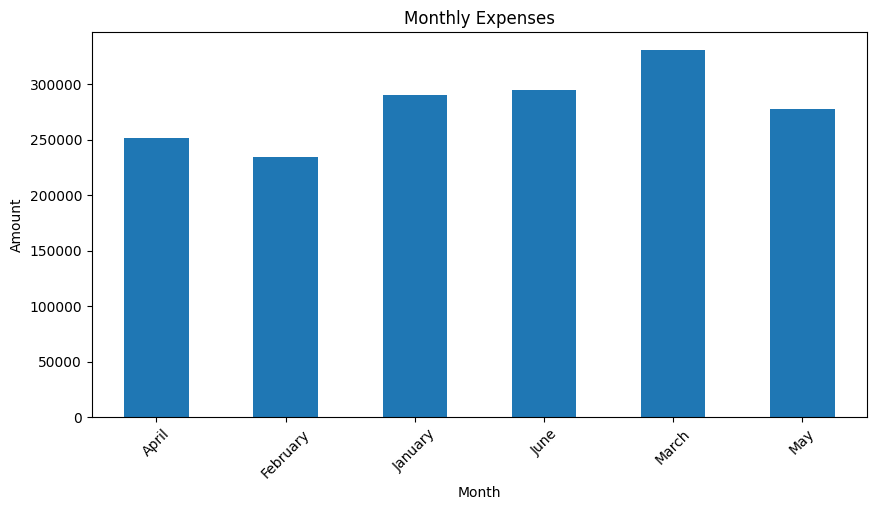

In [ ]:
import matplotlib.pyplot as plt

monthly_summary["Expense"].plot(
    kind="bar",
    figsize=(10,5),
    title="Monthly Expenses"
)

plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.show()

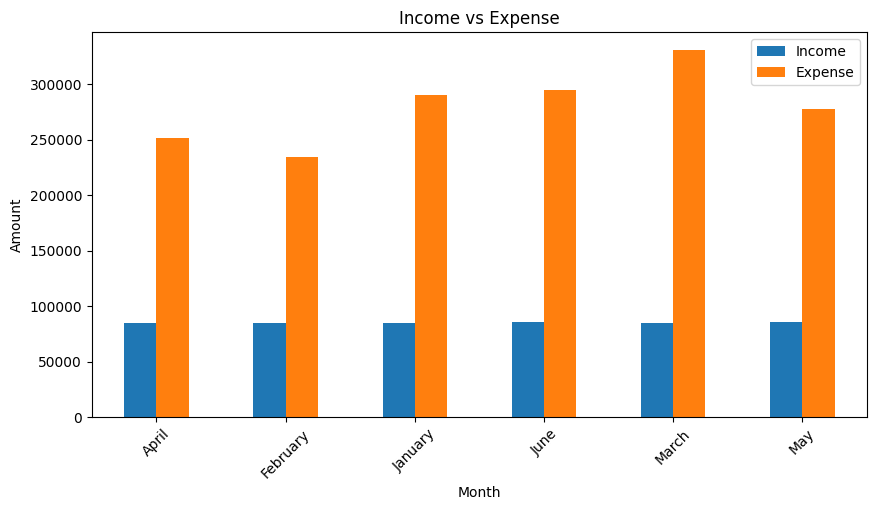

In [ ]:
monthly_summary[["Income","Expense"]].plot(
    kind="bar",
    figsize=(10,5),
    title="Income vs Expense"
)

plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.show()

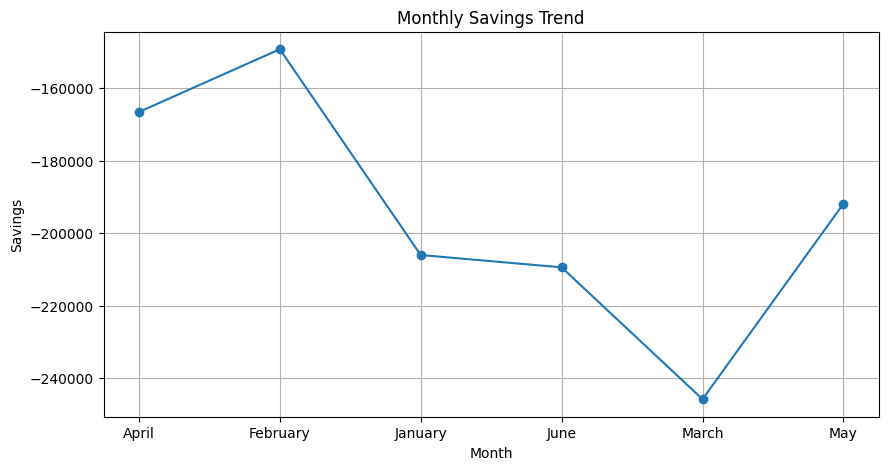

In [ ]:
monthly_summary["Savings"].plot(
    kind="line",
    marker="o",
    figsize=(10,5),
    title="Monthly Savings Trend"
)

plt.xlabel("Month")
plt.ylabel("Savings")

plt.grid(True)

plt.show()

In [ ]:
best_month = monthly_summary["Savings"].idxmax()
worst_month = monthly_summary["Savings"].idxmin()

print("Best Saving Month :", best_month)
print("Worst Saving Month :", worst_month)

Best Saving Month : February
Worst Saving Month : March


In [ ]:
print("="*60)
print("FEATURE 5 : MONTHLY TRENDS")
print("="*60)

print("Months Analysed :", len(monthly_summary))
print("Best Saving Month :", best_month)
print("Worst Saving Month :", worst_month)

print("="*60)
print("Feature 5 Completed Successfully ✅")

FEATURE 5 : MONTHLY TRENDS
Months Analysed : 6
Best Saving Month : February
Worst Saving Month : March
Feature 5 Completed Successfully ✅


Feature 6 - Time Analysis

In [56]:
print(df["Time"].head(20))

0     03:11
1     05:44
2     09:35
3     14:07
4     14:23
5     14:48
6     14:50
7     21:44
8     05:18
9     06:55
10    07:26
11    07:39
12    11:29
13    12:35
14    14:01
15    15:42
16    20:58
17    22:33
18    00:55
19    11:29
Name: Time, dtype: object


In [57]:
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M", errors="coerce")

print(df["Time"].head())
print("Invalid Time Values:", df["Time"].isnull().sum())

0   1900-01-01 03:11:00
1   1900-01-01 05:44:00
2   1900-01-01 09:35:00
3   1900-01-01 14:07:00
4   1900-01-01 14:23:00
Name: Time, dtype: datetime64[ns]
Invalid Time Values: 0


In [58]:

# Extract Hour

df["Hour"] = df["Time"].dt.hour

print(df[["Time", "Hour"]].head())

                 Time  Hour
0 1900-01-01 03:11:00     3
1 1900-01-01 05:44:00     5
2 1900-01-01 09:35:00     9
3 1900-01-01 14:07:00    14
4 1900-01-01 14:23:00    14


In [59]:
# Create Time Slot

def time_slot(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df["Time Slot"] = df["Hour"].apply(time_slot)

print(df[["Hour", "Time Slot"]].head())

   Hour  Time Slot
0     3      Night
1     5    Morning
2     9    Morning
3    14  Afternoon
4    14  Afternoon


In [60]:
time_slot_count = df["Time Slot"].value_counts()

print(time_slot_count)

Time Slot
Morning      354
Evening      340
Afternoon    314
Night        302
Name: count, dtype: int64


In [61]:
time_spending = (
    df[df["Type"] == "debit"]
    .groupby("Time Slot")["Amount"]
    .sum()
)

print(time_spending)

Time Slot
Afternoon    452169.0
Evening      363884.0
Morning      501130.0
Night        361718.0
Name: Amount, dtype: float64


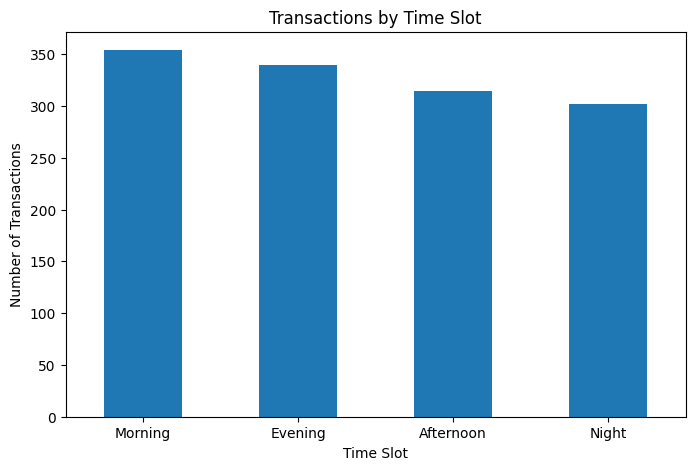

In [62]:
import matplotlib.pyplot as plt

time_slot_count.plot(
    kind="bar",
    figsize=(8,5),
    title="Transactions by Time Slot"
)

plt.xlabel("Time Slot")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

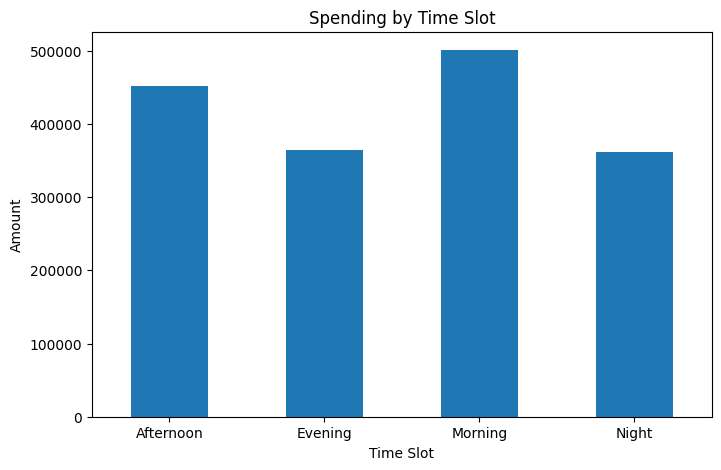

In [63]:
time_spending.plot(
    kind="bar",
    figsize=(8,5),
    title="Spending by Time Slot"
)

plt.xlabel("Time Slot")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

In [64]:
most_active = time_slot_count.idxmax()

highest_spending = time_spending.idxmax()

print("Most Active Time Slot :", most_active)
print("Highest Spending Time Slot :", highest_spending)

Most Active Time Slot : Morning
Highest Spending Time Slot : Morning


In [65]:
print("="*60)
print("FEATURE 6 : TIME ANALYSIS")
print("="*60)

print("Most Active Time Slot :", most_active)
print("Highest Spending Time Slot :", highest_spending)

print("="*60)
print("Feature 6 Completed Successfully ✅")

FEATURE 6 : TIME ANALYSIS
Most Active Time Slot : Morning
Highest Spending Time Slot : Morning
Feature 6 Completed Successfully ✅


Feature 7 - Anomaly Detection

In [66]:
# Mean and Standard Deviation

mean_amount = df["Amount"].mean()
std_amount = df["Amount"].std()

print("Mean Transaction Amount :", round(mean_amount,2))
print("Standard Deviation :", round(std_amount,2))

Mean Transaction Amount : 1670.74
Standard Deviation : 6306.35


In [68]:
# Calculate Z-Score

df["Z-Score"] = (df["Amount"] - mean_amount) / std_amount

print(df[["Amount","Z-Score"]].head())

    Amount    Z-Score
0   2462.0   0.125470
1     50.0  -0.257002
2  84728.0  13.170423
3   1828.0   0.024936
4    270.0  -0.222117


In [69]:
# Transactions with |Z| > 3 are considered anomalies

anomalies = df[abs(df["Z-Score"]) > 3]

print("Total Anomalies :", len(anomalies))

Total Anomalies : 8


In [70]:
anomalies[[
    "Date",
    "Description",
    "Vendor",
    "Category",
    "Amount",
    "Type"
]].head(20)

,Date,Description,Vendor,Category,Amount,Type
2,2024-01-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,84728.0,credit
224,2024-02-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,84724.0,credit
269,2024-02-07,UPI-AMAZONPAY@HDFCBANK,Amazon,Shopping,21986.0,debit
438,2024-03-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,84701.0,credit
658,2024-04-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,84736.0,credit
880,2024-05-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,85393.0,credit
1113,2024-06-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,Salary,85492.0,credit
1298,2024-06-26,AMAZONIN MARKETPLACE,Amazon,Shopping,22008.0,debit


In [71]:
top_transactions = df.sort_values(
    by="Amount",
    ascending=False
).head(10)

top_transactions[[
    "Date",
    "Description",
    "Vendor",
    "Amount",
    "Type"
]]

,Date,Description,Vendor,Amount,Type
1113,2024-06-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,85492.0,credit
880,2024-05-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,85393.0,credit
658,2024-04-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,84736.0,credit
2,2024-01-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,84728.0,credit
224,2024-02-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,84724.0,credit
438,2024-03-01,NEFT-TECHCRUSH LABS-SALARY MAY24,TechCrush Labs,84701.0,credit
1298,2024-06-26,AMAZONIN MARKETPLACE,Amazon,22008.0,debit
269,2024-02-07,UPI-AMAZONPAY@HDFCBANK,Amazon,21986.0,debit
475,2024-03-05,UPI-AMAZONPAY@HDFCBANK,Amazon,19917.0,debit
450,2024-03-02,AMAZON IN,Amazon,18273.0,debit


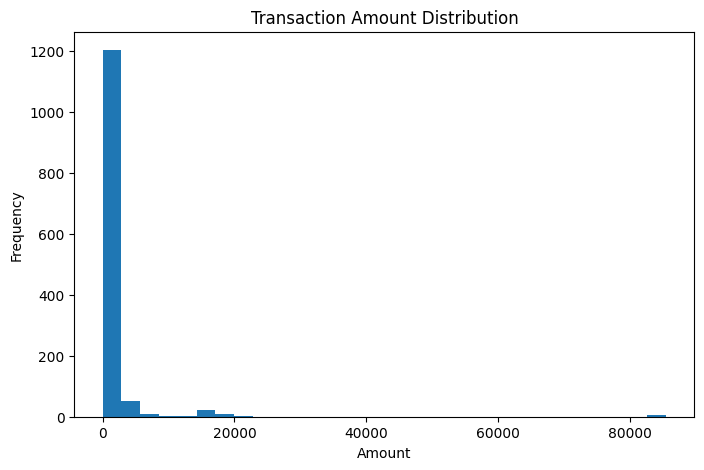

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Amount"], bins=30)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [73]:
print("="*60)
print("FEATURE 7 : ANOMALY DETECTION")
print("="*60)

print("Mean Transaction :", round(mean_amount,2))
print("Standard Deviation :", round(std_amount,2))
print("Total Anomalies :", len(anomalies))
print("Highest Transaction : ₹", df["Amount"].max())

print("="*60)
print("Feature 7 Completed Successfully ✅")

FEATURE 7 : ANOMALY DETECTION
Mean Transaction : 1670.74
Standard Deviation : 6306.35
Total Anomalies : 8
Highest Transaction : ₹ 85492.0
Feature 7 Completed Successfully ✅


Feature 8 - Archetype Detection

In [74]:
category_spending = (
    df[df["Type"] == "debit"]
    .groupby("Category")["Amount"]
    .sum()
)

print(category_spending)

Category
Cafe                28155.0
Cash Withdrawal     45500.0
Dining             117737.0
Entertainment       26764.0
Food Delivery      150839.0
Fuel                89303.0
Groceries          133289.0
Investment         248160.0
Money Transfer      24599.0
Others               6757.0
Rent               108000.0
Shopping           603877.0
Telecom              7334.0
Transport           57474.0
Utilities           31113.0
Name: Amount, dtype: float64


In [75]:
top_category = category_spending.idxmax()
top_amount = category_spending.max()

print("Top Spending Category :", top_category)
print("Amount :", top_amount)

Top Spending Category : Shopping
Amount : 603877.0


In [76]:
def detect_archetype(category):

    if category in ["Food Delivery", "Dining", "Cafe"]:
        return "Foodie 🍔"

    elif category == "Shopping":
        return "Shopaholic 🛍️"

    elif category == "Groceries":
        return "Smart Grocery Shopper 🛒"

    elif category == "Transport":
        return "Daily Commuter 🚌"

    elif category == "Entertainment":
        return "Entertainment Lover 🎬"

    elif category == "Investment":
        return "Investor 📈"

    elif category == "Telecom":
        return "Always Connected 📱"

    elif category == "Utilities":
        return "Responsible Bill Payer 💡"

    elif category == "Fuel":
        return "Frequent Traveler ⛽"

    else:
        return "Balanced Spender 💰"

In [77]:
archetype = detect_archetype(top_category)

print("Financial Archetype :", archetype)

Financial Archetype : Shopaholic 🛍️


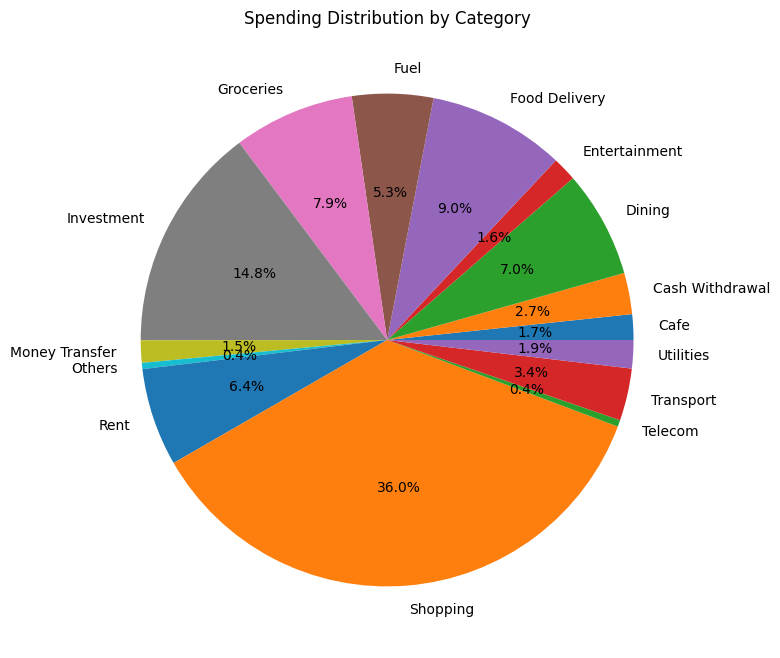

In [78]:
import matplotlib.pyplot as plt

category_spending.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Spending Distribution by Category")
plt.ylabel("")

plt.show()

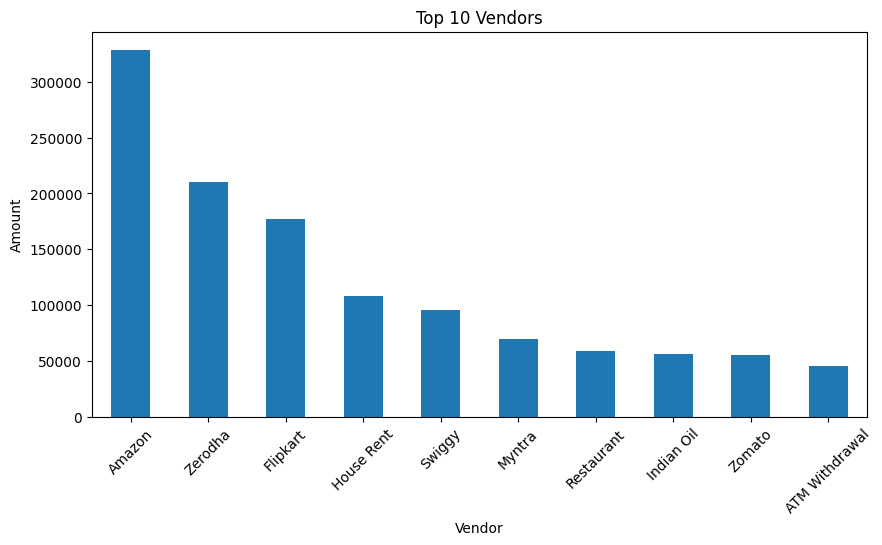

In [79]:
top_vendor_chart = (
    df[df["Type"] == "debit"]
    .groupby("Vendor")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_vendor_chart.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Vendors")
plt.xlabel("Vendor")
plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.show()

In [80]:
print("="*70)
print("               SPENDDNA FINAL REPORT")
print("="*70)

print("Total Transactions :", len(df))
print("Total Credit       : ₹", round(total_credit,2))
print("Total Debit        : ₹", round(total_debit,2))
print("Net Savings        : ₹", round(net_savings,2))
print()

print("Top Spending Category :", top_category)
print("Financial Archetype   :", archetype)
print("Total Anomalies       :", len(anomalies))
print("Best Saving Month     :", best_month)
print("Worst Saving Month    :", worst_month)
print("Most Active Time Slot :", most_active)

print("="*70)
print(" SpendDNA Project Completed Successfully 🎉")
print("="*70)

               SPENDDNA FINAL REPORT
Total Transactions : 1310
Total Credit       : ₹ 509774.0
Total Debit        : ₹ 1678901.0
Net Savings        : ₹ -1169127.0

Top Spending Category : Shopping
Financial Archetype   : Shopaholic 🛍️
Total Anomalies       : 8
Best Saving Month     : February
Worst Saving Month    : March
Most Active Time Slot : Morning
 SpendDNA Project Completed Successfully 🎉


Final SpendDNA Report

In [81]:
print("="*70)
print("                 SPENDDNA FINAL REPORT")
print("="*70)

print(f"📊 Total Transactions      : {len(df)}")
print(f"💰 Total Credit            : ₹ {total_credit:,.2f}")
print(f"💸 Total Debit             : ₹ {total_debit:,.2f}")
print(f"💵 Net Savings             : ₹ {net_savings:,.2f}")

print("-"*70)

print(f"🏆 Top Spending Category   : {top_category}")
print(f"👤 Financial Archetype     : {archetype}")
print(f"⚠️ Total Anomalies         : {len(anomalies)}")

print("-"*70)

print(f"📅 Best Saving Month       : {best_month}")
print(f"📉 Worst Saving Month      : {worst_month}")
print(f"⏰ Most Active Time Slot   : {most_active}")

print("-"*70)

print("📌 Project Summary")
print("✔ Feature 1 : Transaction Parser")
print("✔ Feature 2 : Vendor Extractor")
print("✔ Feature 3 : Category Tagger")
print("✔ Feature 4 : Spending Overview")
print("✔ Feature 5 : Monthly Trends")
print("✔ Feature 6 : Time Analysis")
print("✔ Feature 7 : Anomaly Detection")
print("✔ Feature 8 : Financial Archetype Detection")

print("="*70)
print("🎉 SpendDNA Project Completed Successfully 🎉")
print("="*70)

                 SPENDDNA FINAL REPORT
📊 Total Transactions      : 1310
💰 Total Credit            : ₹ 509,774.00
💸 Total Debit             : ₹ 1,678,901.00
💵 Net Savings             : ₹ -1,169,127.00
----------------------------------------------------------------------
🏆 Top Spending Category   : Shopping
👤 Financial Archetype     : Shopaholic 🛍️
⚠️ Total Anomalies         : 8
----------------------------------------------------------------------
📅 Best Saving Month       : February
📉 Worst Saving Month      : March
⏰ Most Active Time Slot   : Morning
----------------------------------------------------------------------
📌 Project Summary
✔ Feature 1 : Transaction Parser
✔ Feature 2 : Vendor Extractor
✔ Feature 3 : Category Tagger
✔ Feature 4 : Spending Overview
✔ Feature 5 : Monthly Trends
✔ Feature 6 : Time Analysis
✔ Feature 7 : Anomaly Detection
✔ Feature 8 : Financial Archetype Detection
🎉 SpendDNA Project Completed Successfully 🎉
